# Shapiq Vision Under Noise
### How does the explainer's attribution change as the input image gets noisier?

## What this notebook does

We reuse the exact Shapiq Vision setup from `comparison_of_methods.ipynb` - same model (ResNet-18), same superpixel segmentation, same mean-color masking - and add one thing: Gaussian noise injected into the image before it's explained, at several increasing noise levels. We then compare the resulting explanations side by side to see how stable Shapiq Vision's attributions are as noise increases.

In [1]:
# shapiq.vision is not on PyPI yet - install shapiq from the project fork
!pip install "git+https://github.com/S2k-1/shapiq.git@feature/protocols" --quiet

## 1 · Setup

In [2]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from PIL import Image
from torchvision import models, transforms
from skimage.segmentation import slic, mark_boundaries

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 2 · Config

- `IMAGE_PATH` - the image to explain.
- `N_SEGMENTS` - target number of superpixels (players in the game).
- `BUDGET` - number of value-function evaluations Shapiq Vision is allowed.
- `NOISE_LEVELS` - Gaussian noise standard deviations to test, in the same [0, 255] pixel scale as `image_np`. `0.0` gives the clean baseline.

In [36]:
IMAGE_PATH = "images/guitardog.png"
N_SEGMENTS = 50
BUDGET = 1024

MAX_ORDER = 1
INDEX = "SV"

NOISE_LEVELS = [0.0, 15.0, 30.0, 45.0]   # std, in [0, 255] pixel scale; 0.0 = clean


## 3 · Load the image and the model

We will use a pretrained ResNet-18 and the dog-with-a-guitar photo. It is a nice stress test: it contains a golden retriever's face, a guitar, a hat, and clothing, so it's interesting to see which regions the explainers credit for the top prediction.

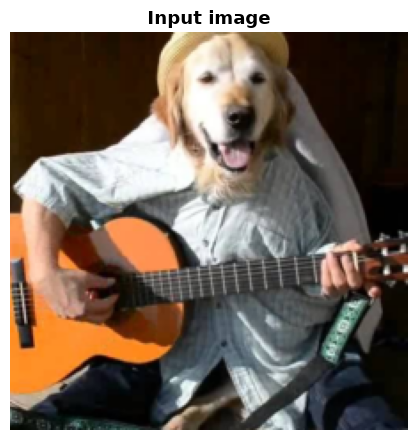

Explaining class: 'acoustic guitar' (40.2%)


In [37]:
pil_image = Image.open(IMAGE_PATH).convert("RGB")

resize_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])
to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resized_image = resize_crop(pil_image)
image_np = np.array(resized_image)                       # (224, 224, 3), for plotting/masking
tensor_image = to_tensor_norm(resized_image).unsqueeze(0).to(device)  # (1, 3, 224, 224)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval().to(device)
categories = weights.meta["categories"]

with torch.no_grad():
    probs_full = torch.softmax(model(tensor_image), dim=1)[0]
top1 = torch.topk(probs_full, 1)
target_class = int(top1.indices[0].item())

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(image_np)
ax.axis("off")
ax.set_title("Input image", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Explaining class: '{categories[target_class]}' ({top1.values[0].item() * 100:.1f}%)")

## 4 · Define the players: superpixel regions

Each superpixel is one "player" in the coalition game.

Same segmentation as the comparison notebook - computed once, on the clean image, and reused for both the clean and noisy runs so the two explanations are directly comparable superpixel-by-superpixel.

Requested 50 superpixels, got 39 players


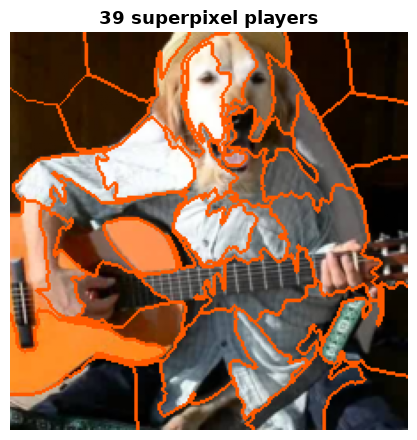

In [38]:
segments = slic(image_np, n_segments=N_SEGMENTS, compactness=12, sigma=1, start_label=0)
n_players = int(segments.max()) + 1
print(f"Requested {N_SEGMENTS} superpixels, got {n_players} players")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(mark_boundaries(image_np, segments, color=(1, 0.35, 0)))
ax.set_title(f"{n_players} superpixel players", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5 · Shapiq Vision setup

We take mean-color masking, superpixels as players and `CountedModel` wrapper to track how many forward passes are used.

In [39]:
from shapiq.vision import CNNArchitecture, ImageExplainer, MeanColorMasking
from shapiq.vision.players import CustomPlayerStrategy

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

class CountedModel(torch.nn.Module):
    """shapiq feeds [0, 1] images, so normalization lives inside the model.
    Counting forward-pass rows keeps budget usage comparable across methods."""

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.n_calls = 0

    def forward(self, x):
        self.n_calls += x.shape[0]
        return self.model(normalize(x))


def run_shapiq_vision(image_for_explainer, class_index):
    counted_model = CountedModel(model).eval().to(device)
    architecture = CNNArchitecture(
        model=counted_model,
        masking_strategy=MeanColorMasking(),
        player_strategy=CustomPlayerStrategy(segments),
    )
    explainer = ImageExplainer(
        model=architecture,
        data=image_for_explainer,
        class_index=class_index,
        index=INDEX,
        max_order=MAX_ORDER,
        random_state=SEED,
    )
    t0 = time.time()
    iv = explainer.explain(budget=BUDGET)
    elapsed = time.time() - t0
    values = iv.get_n_order_values(1)
    return values, elapsed, counted_model.n_calls

## 6 · Run Shapiq Vision at each noise level

For each level in `NOISE_LEVELS`, we add i.i.d. Gaussian noise directly to the [0, 255]-scale image, clip back to valid pixel range, and feed that image into the exact same explainer setup - same segments, same model, same budget. This isolates the effect of noise level from any change in method configuration.

In [40]:
rng = np.random.default_rng(SEED)

noisy_images = []
results = []   # list of (noise_level, values, elapsed, n_calls)

for level in NOISE_LEVELS:
    noise = rng.normal(loc=0.0, scale=level, size=image_np.shape) if level > 0 else np.zeros_like(image_np, dtype=np.float32)
    image_noisy = np.clip(image_np.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    noisy_images.append(image_noisy)

    values, elapsed, n_calls = run_shapiq_vision(image_noisy, target_class)
    results.append((level, values, elapsed, n_calls))
    print(f"noise std={level:>5.1f}  -  done in {elapsed:.1f}s, {n_calls} model calls")

noise std=  0.0  -  done in 30.4s, 1025 model calls
noise std= 15.0  -  done in 28.4s, 1025 model calls
noise std= 30.0  -  done in 28.0s, 1025 model calls
noise std= 45.0  -  done in 29.6s, 1025 model calls


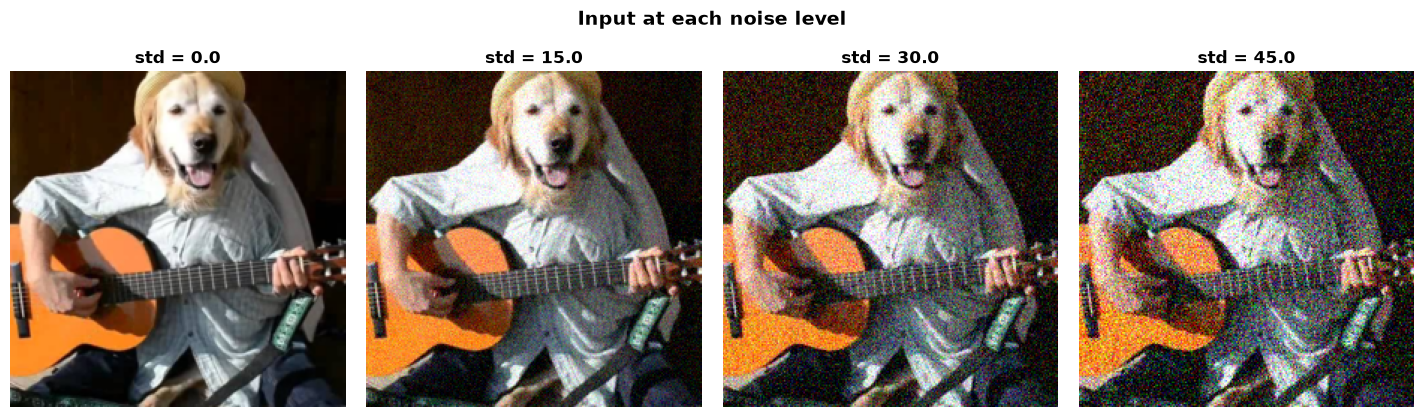

In [41]:
fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(3.6 * len(NOISE_LEVELS), 4))
for ax, level, img in zip(axes, NOISE_LEVELS, noisy_images):
    ax.imshow(img)
    ax.set_title(f"std = {level}", fontsize=12, fontweight="bold")
    ax.axis("off")
fig.suptitle("Input at each noise level", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 7 · Compare attributions across noise levels

All the heatmaps side by side so we can directly compare the effect of adding noise.

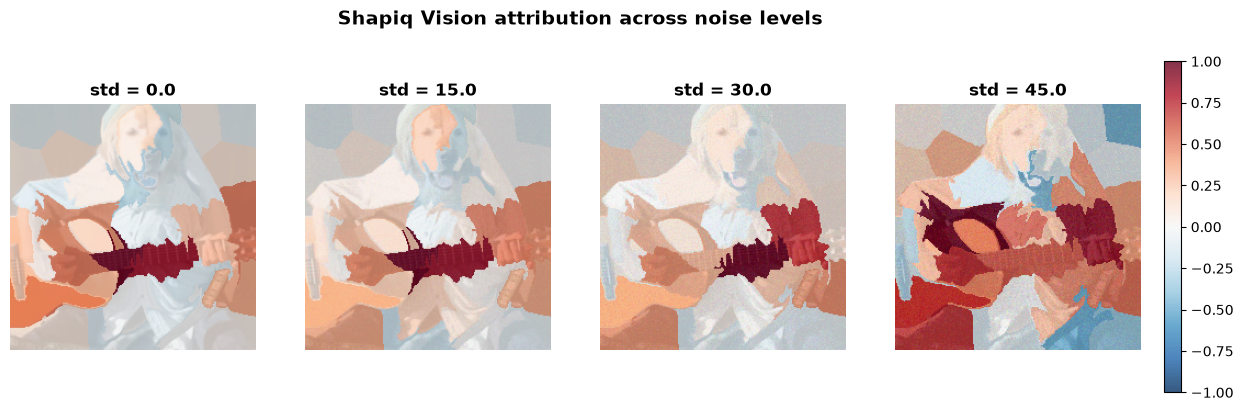

In [42]:
def attribution_map(values, segments):
    out = np.zeros(segments.shape, dtype=np.float32)
    for k, v in enumerate(values):
        out[segments == k] = v
    return out

maps = [attribution_map(values, segments) for _, values, _, _ in results]
maps = [m / np.abs(m).max() for m in maps]   # each map normalized to its own [-1, 1]
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(3.8 * len(NOISE_LEVELS), 4.3))
for ax, level, m, img in zip(axes, NOISE_LEVELS, maps, noisy_images):
    ax.imshow(img)
    im = ax.imshow(m, cmap="RdBu_r", norm=norm, alpha=0.8)
    ax.set_title(f"std = {level}", fontsize=12, fontweight="bold")
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
fig.suptitle("Shapiq Vision attribution across noise levels", fontsize=14, fontweight="bold", y=1.0)
plt.show()

Shapiq Vision deals with noise very well, Resnet-18 on the level of std = 45 seems to be a bit more random, but still shows importance in the area of the guitar